✅ CELL 1 — Imports

In [27]:

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Setup ready ✅")

Setup ready ✅


✅ CELL 2 — Dataset Paths + Classes

In [6]:
# Dataset paths
TRAIN_DIR = Path(r"D:\Real time Sign Language\dataset\train")
VAL_DIR   = Path(r"D:\Real time Sign Language\dataset\validation")

# One-hand alphabets
ONE_HAND_CLASSES = ["C", "I", "L", "O", "U", "V"]

# Two-hand alphabets
TWO_HAND_CLASSES = [
    "A", "B", "D", "E", "F", "G", "H", "J", "K",
    "M", "N", "P", "Q", "R", "S", "T", "W", "X", "Y", "Z"
]

ALL_CLASSES = sorted(ONE_HAND_CLASSES + TWO_HAND_CLASSES)

print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Total classes:", len(ALL_CLASSES))

Train exists: True
Validation exists: True
Total classes: 26


✅ CELL 3 — Count Images per Class

In [7]:
def count_images(folder):
    counts = {}

    for class_name in sorted(os.listdir(folder)):
        class_path = folder / class_name

        if class_path.is_dir():
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            counts[class_name] = len(images)

    return counts


train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)

print("Train classes:", len(train_counts))
print("Validation classes:", len(val_counts))

Train classes: 26
Validation classes: 26


✅ CELL 4 — Convert to DataFrame

In [8]:
df = pd.DataFrame({
    "Class": ALL_CLASSES,
    "Train": [train_counts.get(c, 0) for c in ALL_CLASSES],
    "Validation": [val_counts.get(c, 0) for c in ALL_CLASSES]
})

df["Hand_Type"] = df["Class"].apply(
    lambda x: "One-Hand" if x in ONE_HAND_CLASSES else "Two-Hand"
)

df

,Class,Train,Validation,Hand_Type
0,A,2150,538,Two-Hand
1,B,2260,566,Two-Hand
2,C,2243,561,One-Hand
3,D,2280,570,Two-Hand
4,E,2102,526,Two-Hand
5,F,2020,505,Two-Hand
6,G,2443,611,Two-Hand
7,H,1983,496,Two-Hand
8,I,1911,478,One-Hand
9,J,1996,500,Two-Hand


✅ CELL 5 — Train Data Visualization

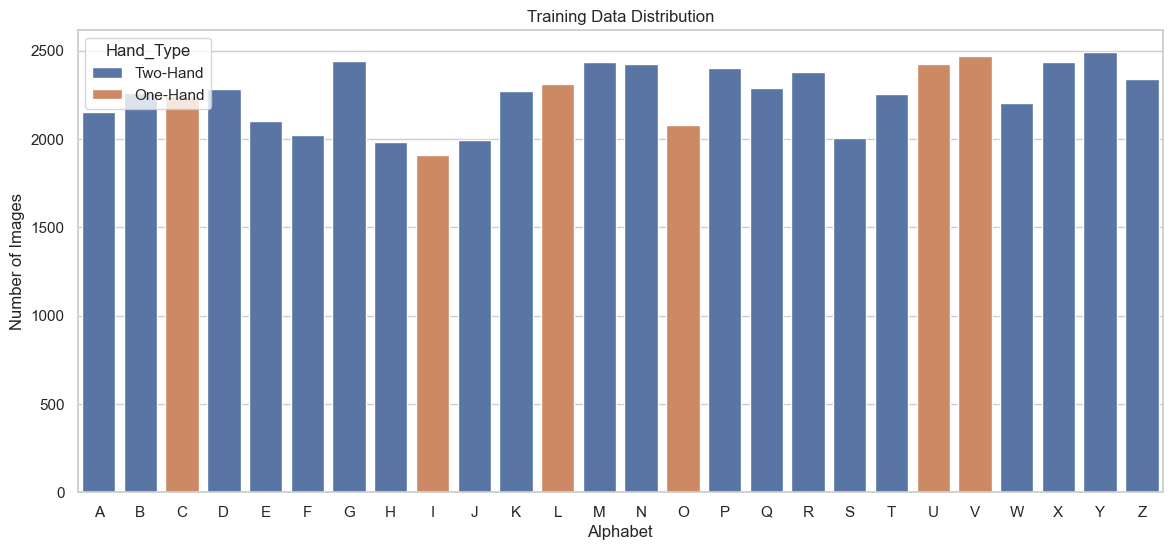

In [9]:
plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Class", y="Train", hue="Hand_Type")
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Alphabet")
plt.show()

✅ CELL 6 — Validation Data Visualization

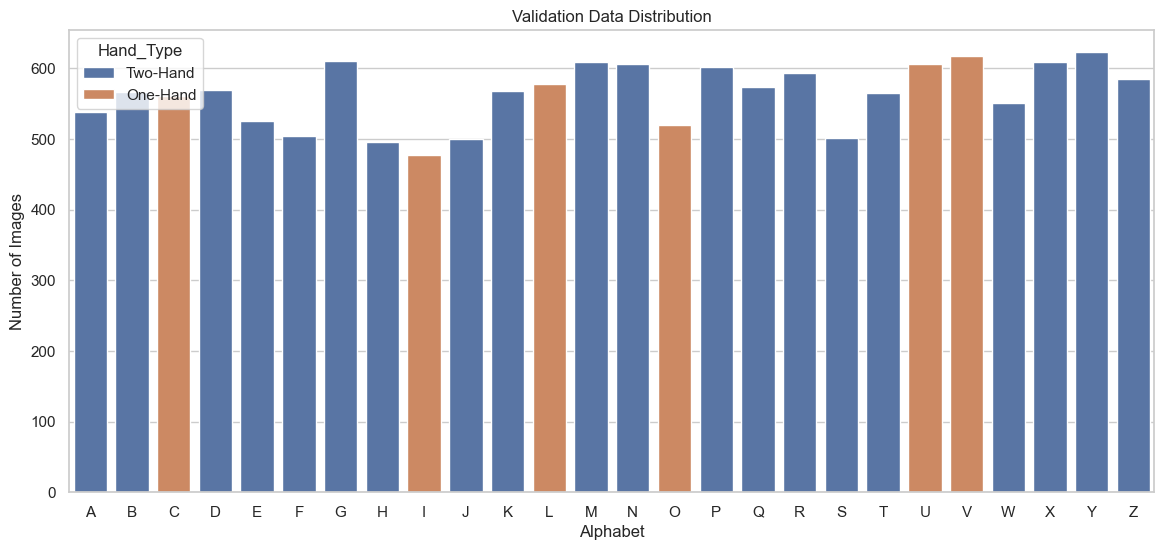

In [10]:
plt.figure(figsize=(14,6))
sns.barplot(data=df, x="Class", y="Validation", hue="Hand_Type")
plt.title("Validation Data Distribution")
plt.ylabel("Number of Images")
plt.xlabel("Alphabet")
plt.show()

✅ CELL 7 — Sanity Check

In [11]:
missing_train = [c for c in ALL_CLASSES if c not in train_counts]
missing_val = [c for c in ALL_CLASSES if c not in val_counts]

print("Missing in train:", missing_train if missing_train else "None ✅")
print("Missing in val:", missing_val if missing_val else "None ✅")

print("\nTrain stats:")
print(df["Train"].describe())

print("\nValidation stats:")
print(df["Validation"].describe())

Missing in train: None ✅
Missing in val: None ✅

Train stats:
count      26.000000
mean     2253.538462
std       173.221761
min      1911.000000
25%      2114.000000
50%      2275.000000
75%      2419.000000
max      2491.000000
Name: Train, dtype: float64

Validation stats:
count     26.000000
mean     563.807692
std       43.298978
min      478.000000
25%      529.000000
50%      569.000000
75%      605.000000
max      623.000000
Name: Validation, dtype: float64


✅ CELL 8 — Imports for image handling + MediaPipe

In [2]:
import cv2
import random
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("OpenCV + MediaPipe loaded successfully ✅")

OpenCV + MediaPipe loaded successfully ✅


✅ CELL 9 — Utility: pick random images from a class

In [3]:
def get_random_images(class_name, split="train", n=4):
    base_dir = TRAIN_DIR if split == "train" else VAL_DIR
    class_path = base_dir / class_name

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    sampled = random.sample(image_files, min(n, len(image_files)))
    return [class_path / img for img in sampled]

✅ CELL 10 — Show raw images from a chosen class

In [4]:
def show_images(image_paths, title="Sample Images"):
    fig, axes = plt.subplots(1, len(image_paths), figsize=(16, 5))
    if len(image_paths) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, image_paths):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(img_path.name)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

✅ CELL 11 — Function to detect hands in a single image

In [6]:
def detect_hands_in_image(image_path, max_num_hands=2):
    image = cv2.imread(str(image_path))
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=max_num_hands,
        min_detection_confidence=0.5
    ) as hands:
        results = hands.process(image_rgb)

    return image, image_rgb, results

✅ CELL 12 — Visualize detection + print hand count

In [7]:
def visualize_hand_detection(image_path):
    image_bgr, image_rgb, results = detect_hands_in_image(image_path)

    annotated = image_rgb.copy()
    hand_count = 0
    handedness_list = []

    if results.multi_hand_landmarks:
        hand_count = len(results.multi_hand_landmarks)

        for idx, hand_landmarks in enumerate(results.multi_hand_landmarks):
            mp_drawing.draw_landmarks(
                annotated,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

        if results.multi_handedness:
            for handedness in results.multi_handedness:
                handedness_list.append(handedness.classification[0].label)

    plt.figure(figsize=(6,6))
    plt.imshow(annotated)
    plt.title(f"{Path(image_path).name} | Detected Hands: {hand_count} | {handedness_list}")
    plt.axis("off")
    plt.show()

    print(f"Image: {image_path.name}")
    print(f"Detected hand count: {hand_count}")
    print(f"Handedness: {handedness_list}")

✅ CELL 13 — Test on a few images manually

In [10]:
from pathlib import Path

# -----------------------------
# FINAL DATASET PATHS
# -----------------------------
TRAIN_DIR = Path(r"D:\Real time Sign Language\dataset\train")
VAL_DIR   = Path(r"D:\Real time Sign Language\dataset\validation")

# -----------------------------
# CLASS CATEGORIES
# -----------------------------
ONE_HAND_CLASSES = ["C", "I", "L", "O", "U", "V"]

TWO_HAND_CLASSES = [
    "A", "B", "D", "E", "F", "G", "H", "J", "K",
    "M", "N", "P", "Q", "R", "S", "T", "W", "X", "Y", "Z"
]

ALL_CLASSES = sorted(ONE_HAND_CLASSES + TWO_HAND_CLASSES)

print("TRAIN_DIR:", TRAIN_DIR)
print("VAL_DIR:", VAL_DIR)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())

TRAIN_DIR: D:\Real time Sign Language\dataset\train
VAL_DIR: D:\Real time Sign Language\dataset\validation
Train exists: True
Validation exists: True


In [11]:
import os
import random
import cv2
import matplotlib.pyplot as plt

def list_image_files(class_name, split="train"):
    base_dir = TRAIN_DIR if split == "train" else VAL_DIR
    class_path = base_dir / class_name

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    return image_files
    

In [12]:
def get_random_images(class_name, split="train", n=4):
    base_dir = TRAIN_DIR if split == "train" else VAL_DIR
    class_path = base_dir / class_name

    if not class_path.exists():
        raise FileNotFoundError(f"Class folder not found: {class_path}")

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    if len(image_files) == 0:
        raise ValueError(f"No valid image files found in: {class_path}")

    sampled = random.sample(image_files, min(n, len(image_files)))
    return [class_path / img for img in sampled]

In [13]:
def show_images(image_paths, title="Sample Images"):
    if len(image_paths) == 0:
        print("No images to display.")
        return

    fig, axes = plt.subplots(1, len(image_paths), figsize=(16, 5))
    if len(image_paths) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, image_paths):
        img = cv2.imread(str(img_path))

        if img is None:
            ax.set_title(f"Failed to load\n{Path(img_path).name}")
            ax.axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(Path(img_path).name)
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [14]:
sample_c = get_random_images("C", split="train", n=4)
sample_a = get_random_images("A", split="train", n=4)

print("Sample C paths:", sample_c)
print("Sample A paths:", sample_a)

Sample C paths: [WindowsPath('D:/Real time Sign Language/dataset/train/C/79.jpg'), WindowsPath('D:/Real time Sign Language/dataset/train/C/960.png'), WindowsPath('D:/Real time Sign Language/dataset/train/C/675.png'), WindowsPath('D:/Real time Sign Language/dataset/train/C/362.jpg')]
Sample A paths: [WindowsPath('D:/Real time Sign Language/dataset/train/A/475.jpg'), WindowsPath('D:/Real time Sign Language/dataset/train/A/580.png'), WindowsPath('D:/Real time Sign Language/dataset/train/A/321.jpg'), WindowsPath('D:/Real time Sign Language/dataset/train/A/A179.jpg')]


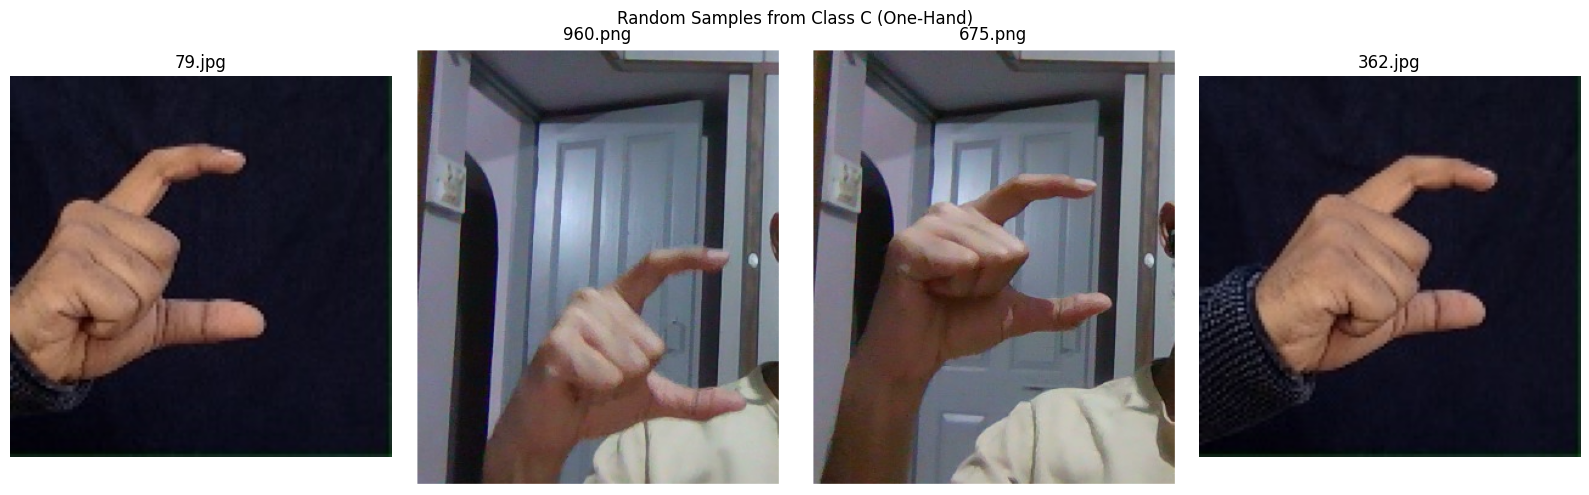

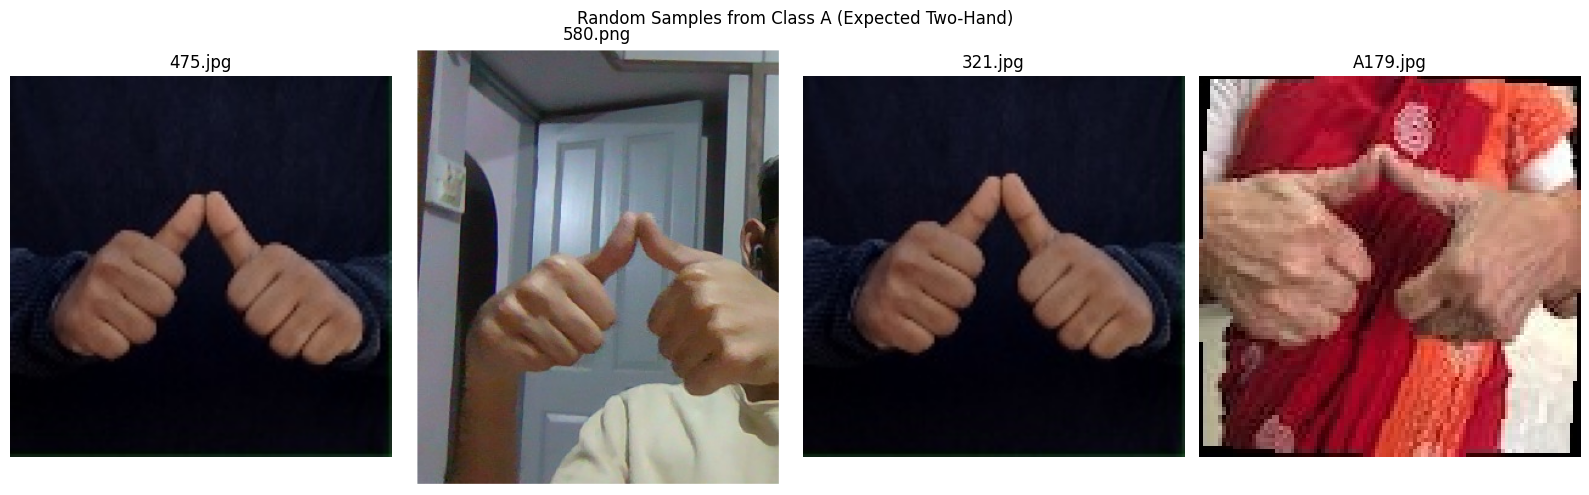

In [15]:
show_images(sample_c, title="Random Samples from Class C (One-Hand)")
show_images(sample_a, title="Random Samples from Class A (Expected Two-Hand)")

In [17]:
import mediapipe as mp

mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

print("MediaPipe setup ready ✅")

MediaPipe setup ready ✅


In [18]:
def visualize_hand_detection(image_path):
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Failed to load image: {image_path}")
        return

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:
        results = hands.process(image_rgb)

    annotated = image_rgb.copy()
    hand_count = 0
    handedness_list = []

    if results.multi_hand_landmarks:
        hand_count = len(results.multi_hand_landmarks)

        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS
            )

        if results.multi_handedness:
            for handedness in results.multi_handedness:
                handedness_list.append(handedness.classification[0].label)

    plt.figure(figsize=(6, 6))
    plt.imshow(annotated)
    plt.title(f"{Path(image_path).name} | Hands: {hand_count} | {handedness_list}")
    plt.axis("off")
    plt.show()

    print(f"Image: {Path(image_path).name}")
    print(f"Detected hand count: {hand_count}")
    print(f"Handedness: {handedness_list}")

c:\Users\LOMESH\.conda\envs\pytorch_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


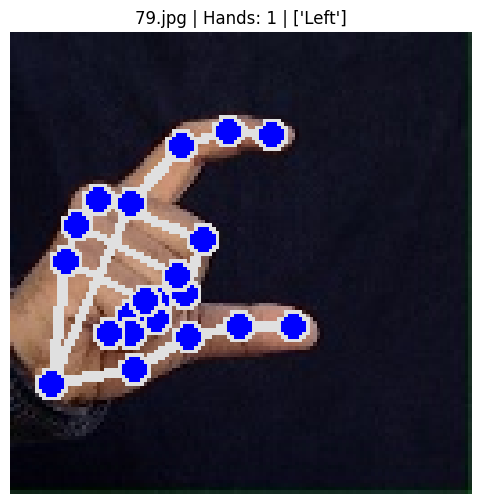

Image: 79.jpg
Detected hand count: 1
Handedness: ['Left']


In [19]:
visualize_hand_detection(sample_c[0])

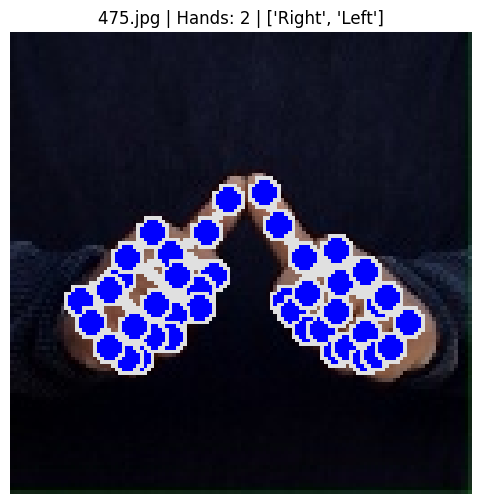

Image: 475.jpg
Detected hand count: 2
Handedness: ['Right', 'Left']


In [20]:
visualize_hand_detection(sample_a[0])

✅ CELL 14 — Extract landmarks from a single detected hand

In [22]:
def extract_single_hand_landmarks(hand_landmarks):
    coords = []
    for lm in hand_landmarks.landmark:
        coords.extend([lm.x, lm.y, lm.z])
    return coords

✅ CELL 15 — Normalize one hand landmarks

In [23]:
def normalize_hand_landmarks(landmarks):
    """
    landmarks: list of 63 values [x1, y1, z1, ..., x21, y21, z21]
    Normalize relative to wrist (landmark 0) and scale.
    """
    arr = np.array(landmarks).reshape(21, 3)

    # Use wrist as origin
    wrist = arr[0]
    arr = arr - wrist

    # Scale to make size-invariant
    max_val = np.max(np.abs(arr))
    if max_val > 0:
        arr = arr / max_val

    return arr.flatten().tolist()

✅ CELL 16 — Core feature extraction function

In [24]:
def extract_features_from_image(image_path, expected_hand_count):
    image = cv2.imread(str(image_path))

    if image is None:
        return None, "image_load_failed"

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with mp_hands.Hands(
        static_image_mode=True,
        max_num_hands=2,
        min_detection_confidence=0.5
    ) as hands:
        results = hands.process(image_rgb)

    if not results.multi_hand_landmarks:
        return None, "no_hands_detected"

    detected_hand_count = len(results.multi_hand_landmarks)

    if detected_hand_count != expected_hand_count:
        return None, f"expected_{expected_hand_count}_got_{detected_hand_count}"

    # -------------------------
    # ONE-HAND CASE
    # -------------------------
    if expected_hand_count == 1:
        hand_landmarks = results.multi_hand_landmarks[0]
        features = extract_single_hand_landmarks(hand_landmarks)
        features = normalize_hand_landmarks(features)
        return features, "success"

    # -------------------------
    # TWO-HAND CASE
    # -------------------------
    elif expected_hand_count == 2:
        hand_data = []

        for idx, hand_landmarks in enumerate(results.multi_hand_landmarks):
            label = results.multi_handedness[idx].classification[0].label  # Left / Right
            coords = extract_single_hand_landmarks(hand_landmarks)
            coords = normalize_hand_landmarks(coords)
            hand_data.append((label, coords))

        # Ensure fixed order: Left first, Right second
        hand_data_sorted = sorted(hand_data, key=lambda x: 0 if x[0] == "Left" else 1)

        labels_found = [x[0] for x in hand_data_sorted]

        if labels_found != ["Left", "Right"]:
            return None, f"invalid_handedness_{labels_found}"

        combined_features = hand_data_sorted[0][1] + hand_data_sorted[1][1]
        return combined_features, "success"

    return None, "unexpected_case"

✅ CELL 17 — Test one-hand feature extraction

In [28]:
features_c, status_c = extract_features_from_image(sample_c[0], expected_hand_count=1)

print("One-Hand Test")
print("Status:", status_c)
print("Feature length:", len(features_c) if features_c else None)
print("First 10 features:", features_c[:10] if features_c else None)

One-Hand Test
Status: success
Feature length: 63
First 10 features: [0.0, 0.0, 0.0, 0.32449391823795226, -0.05092726501670098, -0.029056044384356935, 0.5374275856402525, -0.18393503622561044, -0.126855422343424, 0.7468414921462166]


c:\Users\LOMESH\.conda\envs\pytorch_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


✅ CELL 18 — Test two-hand feature extraction

In [29]:
features_a, status_a = extract_features_from_image(sample_a[0], expected_hand_count=2)

print("Two-Hand Test")
print("Status:", status_a)
print("Feature length:", len(features_a) if features_a else None)
print("First 10 features:", features_a[:10] if features_a else None)    

Two-Hand Test
Status: success
Feature length: 126
First 10 features: [0.0, 0.0, 0.0, 0.2756746292168529, -0.1580134969301579, -0.10965091788708513, 0.6061844598753107, -0.3286860497595572, -0.19837335497583897, 0.8454425742776263]


✅ CELL 19 — Helper to process a small subset of a class

In [31]:
from tqdm import tqdm

def process_class_subset(class_name, split="train", max_images=10):
    """
    Process a small subset of images for a given class.
    Returns:
        rows: list of extracted feature rows
        rejects: list of reject logs
    """
    base_dir = TRAIN_DIR if split == "train" else VAL_DIR
    class_path = base_dir / class_name

    expected_hand_count = 1 if class_name in ONE_HAND_CLASSES else 2

    image_files = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]

    image_files = image_files[:max_images]

    rows = []
    rejects = []

    for img_file in tqdm(image_files, desc=f"{split.upper()} - {class_name}"):
        img_path = class_path / img_file

        features, status = extract_features_from_image(img_path, expected_hand_count)

        if status == "success":
            row = features + [class_name]
            rows.append(row)
        else:
            rejects.append({
                "split": split,
                "class": class_name,
                "image": img_file,
                "reason": status
            })

    return rows, rejects

✅ CELL 20 — Test subset extraction on one one-hand class and one two-hand class

In [32]:
rows_c, rejects_c = process_class_subset("C", split="train", max_images=10)
rows_a, rejects_a = process_class_subset("A", split="train", max_images=10)

print("Class C:")
print("  Successful rows:", len(rows_c))
print("  Rejected rows:", len(rejects_c))

print("\nClass A:")
print("  Successful rows:", len(rows_a))
print("  Rejected rows:", len(rejects_a))

TRAIN - A: 100%|██████████| 10/10 [00:01<00:00,  5.40it/s]

Class C:
  Successful rows: 10
  Rejected rows: 0

Class A:
  Successful rows: 7
  Rejected rows: 3


✅ CELL 21 — Check feature lengths inside extracted rows

In [33]:
print("Class C first row length (including label):", len(rows_c[0]) if rows_c else None)
print("Class A first row length (including label):", len(rows_a[0]) if rows_a else None)

Class C first row length (including label): 64
Class A first row length (including label): 127


✅ CELL 22 — Preview reject logs

In [34]:
print("Rejects from C:")
pd.DataFrame(rejects_c).head()

Rejects from C:


""


In [35]:
print("Rejects from A:")
pd.DataFrame(rejects_a).head()

Rejects from A:


,split,class,image,reason
0,train,A,1000.png,no_hands_detected
1,train,A,1001.png,no_hands_detected
2,train,A,1002.png,no_hands_detected


✅ CELL 23 — Process multiple classes

In [36]:
def process_multiple_classes(class_list, split="train", max_images_per_class=20):
    all_rows = []
    all_rejects = []

    for class_name in class_list:
        rows, rejects = process_class_subset(
            class_name,
            split=split,
            max_images=max_images_per_class
        )
        all_rows.extend(rows)
        all_rejects.extend(rejects)

    return all_rows, all_rejects

✅ CELL 24 — Process one-hand mini train set

In [42]:
one_hand_train_rows, one_hand_train_rejects = process_multiple_classes(
    ONE_HAND_CLASSES,
    split="train",
    max_images_per_class=20
)

print("One-Hand Train Mini Dataset")
print("Successful rows:", len(one_hand_train_rows))
print("Rejected rows:", len(one_hand_train_rejects))

TRAIN - V: 100%|██████████| 20/20 [00:02<00:00,  7.22it/s]

One-Hand Train Mini Dataset
Successful rows: 115
Rejected rows: 5


✅ CELL 25 — Process two-hand mini train set

In [37]:
two_hand_train_rows, two_hand_train_rejects = process_multiple_classes(
    TWO_HAND_CLASSES,
    split="train",
    max_images_per_class=20
)

print("Two-Hand Train Mini Dataset")
print("Successful rows:", len(two_hand_train_rows))
print("Rejected rows:", len(two_hand_train_rejects))

TRAIN - A:   0%|          | 0/20 [00:00<?, ?it/s]c:\Users\LOMESH\.conda\envs\pytorch_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
TRAIN - Z: 100%|██████████| 20/20 [00:02<00:00,  8.16it/s]

Two-Hand Train Mini Dataset
Successful rows: 228
Rejected rows: 172


✅ CELL 26 — Process one-hand mini validation set

In [38]:
one_hand_val_rows, one_hand_val_rejects = process_multiple_classes(
    ONE_HAND_CLASSES,
    split="validation",
    max_images_per_class=20
)

print("One-Hand Validation Mini Dataset")
print("Successful rows:", len(one_hand_val_rows))
print("Rejected rows:", len(one_hand_val_rejects))

VALIDATION - V: 100%|██████████| 20/20 [00:01<00:00, 15.74it/s]

One-Hand Validation Mini Dataset
Successful rows: 118
Rejected rows: 2


✅ CELL 27 — Process two-hand mini validation set

In [39]:
two_hand_val_rows, two_hand_val_rejects = process_multiple_classes(
    TWO_HAND_CLASSES,
    split="validation",
    max_images_per_class=20
)

print("Two-Hand Validation Mini Dataset")
print("Successful rows:", len(two_hand_val_rows))
print("Rejected rows:", len(two_hand_val_rejects))

VALIDATION - Z: 100%|██████████| 20/20 [00:02<00:00,  7.50it/s]

Two-Hand Validation Mini Dataset
Successful rows: 232
Rejected rows: 168


✅ CELL 28 — Convert mini datasets to DataFrames

In [43]:
# Column names
one_hand_columns = [f"f{i}" for i in range(63)] + ["label"]
two_hand_columns = [f"f{i}" for i in range(126)] + ["label"]

# DataFrames
df_one_hand_train = pd.DataFrame(one_hand_train_rows, columns=one_hand_columns)
df_two_hand_train = pd.DataFrame(two_hand_train_rows, columns=two_hand_columns)

df_one_hand_val = pd.DataFrame(one_hand_val_rows, columns=one_hand_columns)
df_two_hand_val = pd.DataFrame(two_hand_val_rows, columns=two_hand_columns)

print("One-Hand Train Shape:", df_one_hand_train.shape)
print("Two-Hand Train Shape:", df_two_hand_train.shape)
print("One-Hand Val Shape:", df_one_hand_val.shape)
print("Two-Hand Val Shape:", df_two_hand_val.shape)

One-Hand Train Shape: (115, 64)
Two-Hand Train Shape: (228, 127)
One-Hand Val Shape: (118, 64)
Two-Hand Val Shape: (232, 127)


✅ CELL 29 — Preview extracted mini datasets

In [44]:
df_one_hand_train.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f54,f55,f56,f57,f58,f59,f60,f61,f62,label
0,0.0,0.0,0.0,0.327762,0.035398,0.002639,0.554045,-0.065400,-0.068633,0.763973,...,0.506315,-0.221765,-0.373801,0.431793,-0.101686,-0.320618,0.328470,-0.106316,-0.274073,C
1,0.0,0.0,0.0,0.323584,0.021945,-0.002215,0.541908,-0.069696,-0.078153,0.748566,...,0.480507,-0.219780,-0.378622,0.408625,-0.101947,-0.321500,0.309954,-0.110027,-0.270414,C
2,0.0,0.0,0.0,0.359434,0.020725,0.004784,0.576171,-0.082112,-0.072195,0.788534,...,0.520800,-0.228043,-0.416170,0.457224,-0.099036,-0.354609,0.348706,-0.105709,-0.301116,C
3,0.0,0.0,0.0,0.350638,0.022335,0.007823,0.571930,-0.077465,-0.072590,0.788191,...,0.516729,-0.238670,-0.434266,0.452885,-0.108793,-0.373808,0.341512,-0.108341,-0.322407,C
4,0.0,0.0,0.0,0.288175,-0.012989,-0.064717,0.558970,-0.087983,-0.185010,0.803476,...,0.189613,-0.304298,-0.464925,0.128304,-0.197208,-0.405612,0.015774,-0.219961,-0.343029,C


In [45]:
df_two_hand_train.head()

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f117,f118,f119,f120,f121,f122,f123,f124,f125,label
0,0.0,0.0,0.0,0.289920,-0.166809,-0.100997,0.612597,-0.368577,-0.188109,0.848019,...,-0.175746,0.392402,-0.350644,-0.105086,0.366594,-0.325359,0.014879,0.290885,-0.314620,A
1,0.0,0.0,0.0,0.282342,-0.181571,-0.092036,0.605204,-0.385824,-0.170632,0.846455,...,-0.194813,0.401870,-0.364756,-0.116381,0.371812,-0.343951,0.012757,0.296499,-0.333241,A
2,0.0,0.0,0.0,0.293979,-0.181138,-0.093074,0.615626,-0.389228,-0.176911,0.851344,...,-0.193360,0.402101,-0.401502,-0.121077,0.364679,-0.384285,0.008171,0.280603,-0.372150,A
3,0.0,0.0,0.0,0.306042,-0.187978,-0.129386,0.640253,-0.366667,-0.213437,0.864860,...,-0.313295,0.479027,-0.495671,-0.237929,0.445039,-0.484299,-0.101077,0.363475,-0.477028,A
4,0.0,0.0,0.0,0.305174,-0.212550,-0.119389,0.625515,-0.426250,-0.201281,0.862206,...,-0.375563,0.473873,-0.478931,-0.302897,0.449450,-0.462885,-0.185176,0.375967,-0.450826,A


✅ CELL 30 — Reject analysis summary

In [46]:
all_mini_rejects = (
    one_hand_train_rejects +
    two_hand_train_rejects +
    one_hand_val_rejects +
    two_hand_val_rejects
)

df_rejects_mini = pd.DataFrame(all_mini_rejects)

print("Total mini rejects:", len(df_rejects_mini))
df_rejects_mini["reason"].value_counts()

Total mini rejects: 347


reason
expected_2_got_1                         252
no_hands_detected                         50
invalid_handedness_['Left', 'Left']       29
invalid_handedness_['Right', 'Right']     15
expected_1_got_2                           1
Name: count, dtype: int64

✅ CELL 31 — Create mini reject DataFrame

In [47]:
df_rejects_mini = pd.DataFrame(all_mini_rejects)
df_rejects_mini.head()

,split,class,image,reason
0,train,U,1000.png,no_hands_detected
1,train,U,1001.jpg,expected_1_got_2
2,train,U,1005.png,no_hands_detected
3,train,U,1006.png,no_hands_detected
4,train,U,1007.png,no_hands_detected


✅ CELL 32 — Reject counts by class

In [49]:
rejects_by_class = df_rejects_mini.groupby(["class", "reason"]).size().reset_index(name="count")
rejects_by_class.sort_values(["class", "count"], ascending=[True, False]).head(20)

,class,reason,count
1,A,no_hands_detected,11
0,A,expected_2_got_1,7
2,B,expected_2_got_1,3
3,B,"invalid_handedness_['Left', 'Left']",1
4,E,expected_2_got_1,2
5,F,expected_2_got_1,16
6,G,expected_2_got_1,1
7,H,expected_2_got_1,40
8,J,expected_2_got_1,24
9,K,expected_2_got_1,1


✅ CELL 33 — Total rejects per class

In [50]:
rejects_summary = df_rejects_mini.groupby("class").size().reset_index(name="total_rejects")
rejects_summary = rejects_summary.sort_values("total_rejects", ascending=False)

rejects_summary

,class,total_rejects
9,P,40
10,Q,40
5,H,40
15,W,36
11,R,35
12,S,29
18,Z,29
6,J,24
0,A,18
3,F,16


✅ CELL 34 — Plot rejects per class

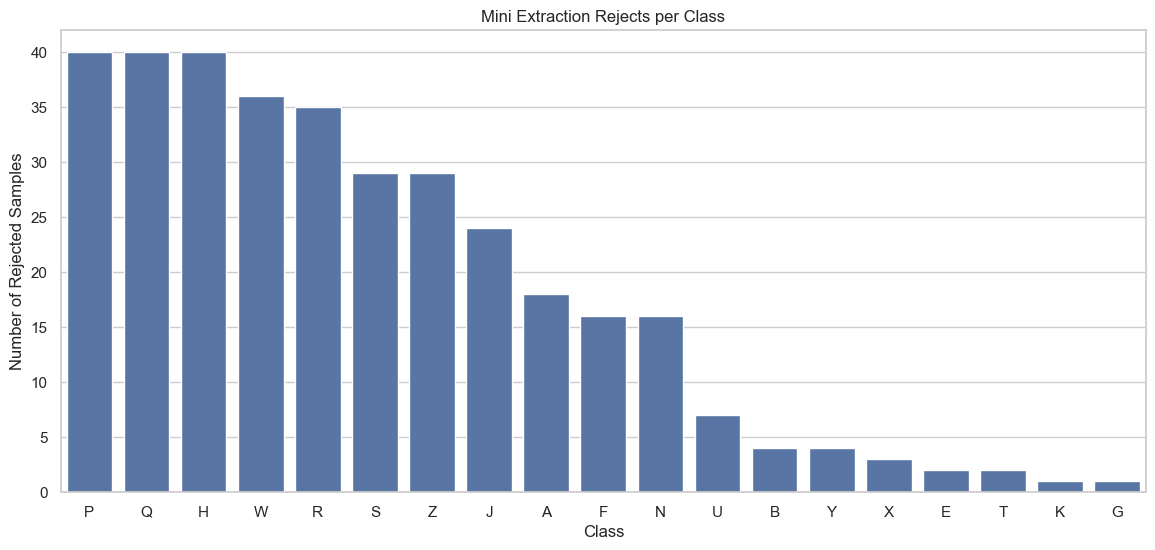

In [51]:
plt.figure(figsize=(14,6))
sns.barplot(data=rejects_summary, x="class", y="total_rejects")
plt.title("Mini Extraction Rejects per Class")
plt.xlabel("Class")
plt.ylabel("Number of Rejected Samples")
plt.xticks(rotation=0)
plt.show()

✅ CELL 35 — Success counts per mini dataset class

In [52]:
one_hand_train_success = df_one_hand_train["label"].value_counts().reset_index()
one_hand_train_success.columns = ["class", "count"]
one_hand_train_success["dataset"] = "one_hand_train"

two_hand_train_success = df_two_hand_train["label"].value_counts().reset_index()
two_hand_train_success.columns = ["class", "count"]
two_hand_train_success["dataset"] = "two_hand_train"

one_hand_val_success = df_one_hand_val["label"].value_counts().reset_index()
one_hand_val_success.columns = ["class", "count"]
one_hand_val_success["dataset"] = "one_hand_val"

two_hand_val_success = df_two_hand_val["label"].value_counts().reset_index()
two_hand_val_success.columns = ["class", "count"]
two_hand_val_success["dataset"] = "two_hand_val"

df_success_summary = pd.concat([
    one_hand_train_success,
    two_hand_train_success,
    one_hand_val_success,
    two_hand_val_success
], ignore_index=True)

df_success_summary.head()

,class,count,dataset
0,C,20,one_hand_train
1,I,20,one_hand_train
2,L,20,one_hand_train
3,O,20,one_hand_train
4,V,20,one_hand_train


✅ CELL 36 — Plot successful extraction counts

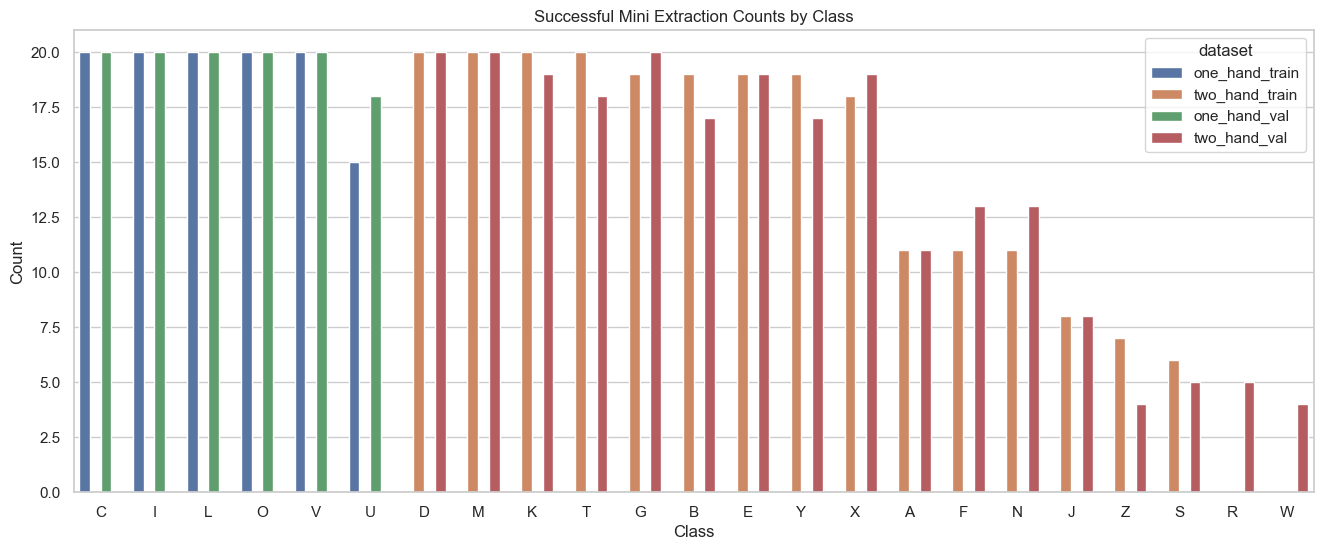

In [53]:
plt.figure(figsize=(16,6))
sns.barplot(data=df_success_summary, x="class", y="count", hue="dataset")
plt.title("Successful Mini Extraction Counts by Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

✅ CELL 37 — Create processed folder path

In [54]:
PROCESSED_DIR = Path(r"D:\sign_language_project\processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Processed folder ready:", PROCESSED_DIR)

Processed folder ready: D:\sign_language_project\processed


✅ CELL 38 — Full dataset processing function

In [55]:
def process_full_dataset(split="train"):
    """
    Processes the full dataset split and returns:
    - one_hand_rows
    - two_hand_rows
    - reject_logs
    """
    base_dir = TRAIN_DIR if split == "train" else VAL_DIR

    one_hand_rows = []
    two_hand_rows = []
    reject_logs = []

    for class_name in ALL_CLASSES:
        class_path = base_dir / class_name
        expected_hand_count = 1 if class_name in ONE_HAND_CLASSES else 2

        image_files = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
        ]

        print(f"\nProcessing {split.upper()} - Class {class_name} ({len(image_files)} images)")

        for img_file in tqdm(image_files, desc=f"{split.upper()} - {class_name}"):
            img_path = class_path / img_file

            features, status = extract_features_from_image(img_path, expected_hand_count)

            if status == "success":
                row = features + [class_name]

                if expected_hand_count == 1:
                    one_hand_rows.append(row)
                else:
                    two_hand_rows.append(row)

            else:
                reject_logs.append({
                    "split": split,
                    "class": class_name,
                    "image": img_file,
                    "reason": status
                })

    return one_hand_rows, two_hand_rows, reject_logs

✅ CELL 39 — Run FULL TRAIN extraction

In [56]:
one_hand_train_rows, two_hand_train_rows, reject_log_train = process_full_dataset(split="train")

print("\nTRAIN EXTRACTION COMPLETE ✅")
print("One-hand train rows:", len(one_hand_train_rows))
print("Two-hand train rows:", len(two_hand_train_rows))
print("Train rejects:", len(reject_log_train))


Processing TRAIN - Class A (2150 images)


TRAIN - A:   0%|          | 0/2150 [00:00<?, ?it/s]c:\Users\LOMESH\.conda\envs\pytorch_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
TRAIN - A: 100%|██████████| 2150/2150 [03:24<00:00, 10.54it/s]



Processing TRAIN - Class B (2260 images)


TRAIN - B: 100%|██████████| 2260/2260 [04:31<00:00,  8.34it/s]



Processing TRAIN - Class C (2243 images)


...


Processing TRAIN - Class Y (2491 images)


TRAIN - Y: 100%|██████████| 2491/2491 [02:52<00:00, 14.46it/s]



Processing TRAIN - Class Z (2337 images)


TRAIN - Z: 100%|██████████| 2337/2337 [02:38<00:00, 14.71it/s]


TRAIN EXTRACTION COMPLETE ✅
One-hand train rows: 11486
Two-hand train rows: 23012
Train rejects: 24094


✅ CELL 40 — Save TRAIN extracted data to CSV

In [57]:
# Column names
one_hand_columns = [f"f{i}" for i in range(63)] + ["label"]
two_hand_columns = [f"f{i}" for i in range(126)] + ["label"]

# Convert to DataFrames
df_one_hand_train = pd.DataFrame(one_hand_train_rows, columns=one_hand_columns)
df_two_hand_train = pd.DataFrame(two_hand_train_rows, columns=two_hand_columns)
df_reject_train = pd.DataFrame(reject_log_train)

# Save to CSV
df_one_hand_train.to_csv(PROCESSED_DIR / "one_hand_train.csv", index=False)
df_two_hand_train.to_csv(PROCESSED_DIR / "two_hand_train.csv", index=False)
df_reject_train.to_csv(PROCESSED_DIR / "reject_log_train.csv", index=False)

print("TRAIN CSV files saved successfully ✅")
print("Saved files:")
print(PROCESSED_DIR / "one_hand_train.csv")
print(PROCESSED_DIR / "two_hand_train.csv")
print(PROCESSED_DIR / "reject_log_train.csv")

TRAIN CSV files saved successfully ✅
Saved files:
D:\sign_language_project\processed\one_hand_train.csv
D:\sign_language_project\processed\two_hand_train.csv
D:\sign_language_project\processed\reject_log_train.csv


✅ CELL 41 — Quick sanity check of saved train data

In [58]:
print("One-Hand Train Shape:", df_one_hand_train.shape)
print("Two-Hand Train Shape:", df_two_hand_train.shape)
print("Reject Train Shape:", df_reject_train.shape)

print("\nOne-Hand Train Label Distribution:")
print(df_one_hand_train["label"].value_counts())

print("\nTwo-Hand Train Label Distribution (Top 10):")
print(df_two_hand_train["label"].value_counts().head(10))

One-Hand Train Shape: (11486, 64)
Two-Hand Train Shape: (23012, 127)
Reject Train Shape: (24094, 4)

One-Hand Train Label Distribution:
label
V    2135
L    2025
C    1979
I    1911
U    1721
O    1715
Name: count, dtype: int64

Two-Hand Train Label Distribution (Top 10):
label
Y    1787
E    1785
D    1732
T    1667
K    1641
A    1534
X    1525
M    1442
G    1395
F    1265
Name: count, dtype: int64


✅ CELL 42 — Run FULL VALIDATION extraction

In [59]:
one_hand_val_rows, two_hand_val_rows, reject_log_val = process_full_dataset(split="validation")

print("\nVALIDATION EXTRACTION COMPLETE ✅")
print("One-hand val rows:", len(one_hand_val_rows))
print("Two-hand val rows:", len(two_hand_val_rows))
print("Validation rejects:", len(reject_log_val))


Processing VALIDATION - Class A (538 images)


VALIDATION - A:   0%|          | 0/538 [00:00<?, ?it/s]c:\Users\LOMESH\.conda\envs\pytorch_env\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
VALIDATION - A: 100%|██████████| 538/538 [00:48<00:00, 11.10it/s]



Processing VALIDATION - Class B (566 images)


VALIDATION - B: 100%|██████████| 566/566 [00:36<00:00, 15.38it/s]



Processing VALIDATION - Class C (561 images)


...


Processing VALIDATION - Class Y (623 images)


VALIDATION - Y: 100%|██████████| 623/623 [00:44<00:00, 14.10it/s]



Processing VALIDATION - Class Z (585 images)


VALIDATION - Z: 100%|██████████| 585/585 [00:38<00:00, 15.08it/s]


VALIDATION EXTRACTION COMPLETE ✅
One-hand val rows: 2847
Two-hand val rows: 5768
Validation rejects: 6044


✅ CELL 43 — Save VALIDATION extracted data to CSV

In [60]:
# Convert validation rows to DataFrames
df_one_hand_val = pd.DataFrame(one_hand_val_rows, columns=one_hand_columns)
df_two_hand_val = pd.DataFrame(two_hand_val_rows, columns=two_hand_columns)
df_reject_val = pd.DataFrame(reject_log_val)

# Save validation CSVs
df_one_hand_val.to_csv(PROCESSED_DIR / "one_hand_val.csv", index=False)
df_two_hand_val.to_csv(PROCESSED_DIR / "two_hand_val.csv", index=False)
df_reject_val.to_csv(PROCESSED_DIR / "reject_log_val.csv", index=False)

print("VALIDATION CSV files saved successfully ✅")
print("Saved files:")
print(PROCESSED_DIR / "one_hand_val.csv")
print(PROCESSED_DIR / "two_hand_val.csv")
print(PROCESSED_DIR / "reject_log_val.csv")

VALIDATION CSV files saved successfully ✅
Saved files:
D:\sign_language_project\processed\one_hand_val.csv
D:\sign_language_project\processed\two_hand_val.csv
D:\sign_language_project\processed\reject_log_val.csv


✅ CELL 44 — Quick validation sanity check

In [61]:
print("One-Hand Val Shape:", df_one_hand_val.shape)
print("Two-Hand Val Shape:", df_two_hand_val.shape)
print("Reject Val Shape:", df_reject_val.shape)

print("\nOne-Hand Validation Label Distribution:")
print(df_one_hand_val["label"].value_counts())

print("\nTwo-Hand Validation Label Distribution (Top 10):")
print(df_two_hand_val["label"].value_counts().head(10))

One-Hand Val Shape: (2847, 64)
Two-Hand Val Shape: (5768, 127)
Reject Val Shape: (6044, 4)

One-Hand Validation Label Distribution:
label
V    525
L    519
C    493
I    477
O    430
U    403
Name: count, dtype: int64

Two-Hand Validation Label Distribution (Top 10):
label
D    447
E    428
Y    428
T    426
K    411
A    397
X    388
M    364
G    363
N    323
Name: count, dtype: int64
